# Step 4: City-level downscaling using identified SED drivers as allocation parameters 

Before running this notebook, please refer to the [Step 4 README](../Step_4/README.md) for instructions on the required input files and folder structure.

This notebook is organized into three main sections:
1. Loading the data files
2. Performing calculations
3. Visualizing city-level results

## Case study

- **Region:** Province of Quebec, Canada
- **Year:** 2021
- **Impact studied:** Climate change short-term
- **Available socioeconomic and demographic (SED) factors:** Income, Household type, Region and Tenure

## Required libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

It is necessary to define the following parameters

In [2]:
YEAR = 2021

IMPACT= "CC"

REGION_FOLDER= "Quebec_cities"

CITIES= {"Montréal",
         "Québec",
         "Joliette",
         "Candiac",
         "Varennes",
         "Sherbrooke",
         "Gatineau",
         "Saguenay",
         "Trois-Rivières"
        }

CATEGORY_DRIVER = {
    "Transportation": "Tenure",
    "Food expenditures": "Type",
    "Shelter": "Type",
    "Household operations, furnishings and, equipment": "Type",
    "Clothing and accessories": "Income",
    "Health and personal care": "Type",
    "Recreation": "Income",
    "Miscellaneous expenditures": "Income",
    "Tobacco, alcohol and non-medical cannabis": "Type",
    "Education and reading materials": "Fixed",
}

FIXED_PH = {
    "Education and reading materials": 104.714936  # kg CO2 eq (short) per household
}

CITY_AVG_HH_SIZE = {
    "Montréal": 2.1,
    "Québec": 2.0,
    "Joliette": 1.9,
    "Candiac": 2.6,
    "Varennes": 2.5,
    "Sherbrooke": 2.1,
    "Gatineau": 2.3,
    "Saguenay": 2.1,
    "Trois-Rivières": 2.0
}

## 1. Loading the data files

The following files contain the environmental impacts per household by consumption category and SED subfactor, generated in Step 2.


In [3]:
df_income = pd.read_excel(f"../Step_2/{YEAR}_{IMPACT}_Income.xlsx")
df_type   = pd.read_excel(f"../Step_2/{YEAR}_{IMPACT}_Type.xlsx")
df_tenure = pd.read_excel(f"../Step_2/{YEAR}_{IMPACT}_Tenure.xlsx")

The following files contain the number of households by SED subfactor for each city, located in the folder specified in REGION_FOLDER. Each file is named {YEAR}_{city}.xlsx.


In [4]:
city_data = {}
for city in CITIES:
    city_clean = city.replace(" ", "_")
    file_path = os.path.join(REGION_FOLDER, f"{YEAR}_{city_clean}.xlsx")
    city_data[city] = pd.read_excel(file_path)

## 2. Performing calculations

This section computes city-level environmental impacts for each consumption category using the category-specific SED drivers identified in Step 3.  Results are exported to `city_results/` as one file per city, named `{YEAR}_{IMPACT}_{city}.xlsx`.

In [5]:
OUTPUT_FOLDER = "city_results"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

results = []

for city in CITIES:
    df_city = city_data[city]
    
    for category, driver in CATEGORY_DRIVER.items():
        
        if driver == "Fixed":
            factor_for_hh = "Income"
            total_hh = df_city[df_city["Factor"] == factor_for_hh]["Households"].sum()
            emission_total = FIXED_PH[category] * total_hh
        else:
            if driver == "Income":
                df_impact = df_income
            elif driver == "Type":
                df_impact = df_type
            else:
                df_impact = df_tenure
            
            df_cat = df_impact[df_impact["Consumption_category"] == category]
            df_hh = df_city[df_city["Factor"] == driver]
            df_merge = df_hh.merge(df_cat, on="Subfactor", how="inner")
            emission_total = (df_merge["Households"] * df_merge["Emission_per_household (kg CO2 eq (short)/household)"]).sum()
            
            factor_for_hh = driver
            total_hh = df_city[df_city["Factor"] == factor_for_hh]["Households"].sum()
        
        emission_total_t = emission_total / 1000
        
        results.append({
            "City": city,
            "Category": category,
            "Driver": driver,
            f"Emission_total (t CO2 eq)": emission_total_t,
            f"Emission_per_household (t CO2 eq/household)": emission_total_t / total_hh,
            f"Emission_per_capita (t CO2 eq/capita)": emission_total_t / (total_hh * CITY_AVG_HH_SIZE[city])
        })

df_results = pd.DataFrame(results)

# Export one file per city
for city in CITIES:
    city_clean = city.replace(" ", "_")
    df_city_results = df_results[df_results["City"] == city].reset_index(drop=True)
    file_path = os.path.join(OUTPUT_FOLDER, f"{YEAR}_{IMPACT}_{city_clean}.xlsx")
    df_city_results.to_excel(file_path, index=False)

df_results

,City,Category,Driver,Emission_total (t CO2 eq),Emission_per_household (t CO2 eq/household),Emission_per_capita (t CO2 eq/capita)
0,Gatineau,Transportation,Tenure,951320.328267,7.521746,3.270324
1,Gatineau,Food expenditures,Type,614539.223235,4.858978,2.112599
2,Gatineau,Shelter,Type,389173.929454,3.077082,1.337862
3,Gatineau,"Household operations, furnishings and, equipment",Type,299054.891926,2.364538,1.028060
4,Gatineau,Clothing and accessories,Income,165656.019238,1.309772,0.569466
...,...,...,...,...,...,...
85,Saguenay,Health and personal care,Type,36989.106594,0.547808,0.260861
86,Saguenay,Recreation,Income,24055.170408,0.356257,0.169646
87,Saguenay,Miscellaneous expenditures,Income,22146.273921,0.327986,0.156184
88,Saguenay,"Tobacco, alcohol and non-medical cannabis",Type,41515.392910,0.614842,0.292782


## 3. Visualizing city-level results

This section generates the city-level emissions figure using the category-specific multi-driver approach. Results are presented as stacked bar charts comparing emissions across cities, expressed per household and per capita.

In [6]:
FIG_WIDTH_IN  = 6.85    # 174 mm
FIG_HEIGHT_IN = 8   
plt.rcParams.update({
    "figure.figsize": (FIG_WIDTH_IN, FIG_HEIGHT_IN),
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,   # editable text in PDF
    "ps.fonttype": 42
})


Saved: 2021_CC_cities.pdf and 2021_CC_cities.png


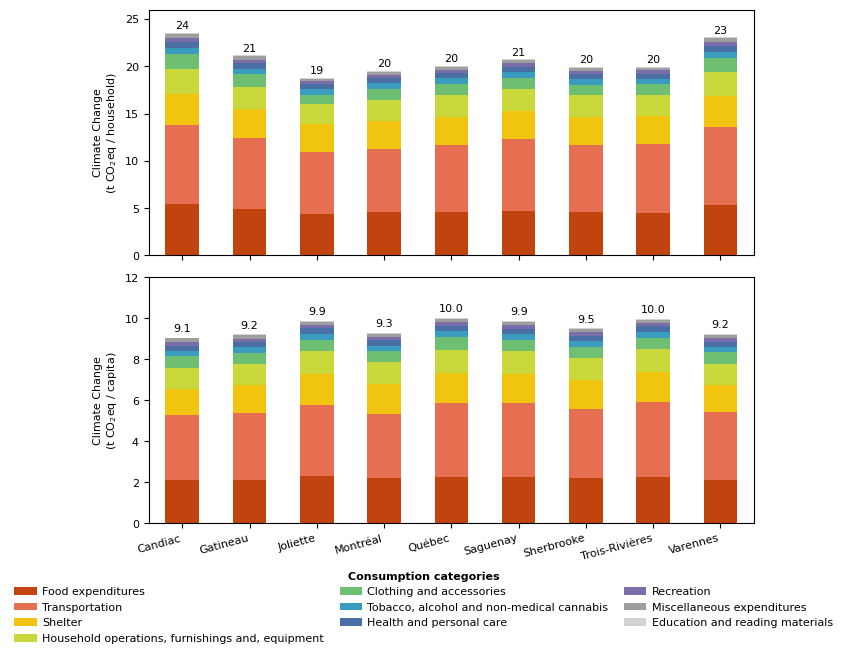

In [7]:
CATEGORY_COLORS = {
    "Food expenditures": "#C1440E",
    "Transportation": "#E76F51",
    "Shelter": "#F1C40F",
    "Household operations, furnishings and, equipment": "#C9D93B",
    "Clothing and accessories": "#6FBF73",
    "Tobacco, alcohol and non-medical cannabis": "#3A9CBF",
    "Health and personal care": "#4A6FA5",
    "Recreation": "#7B6EA8",
    "Miscellaneous expenditures": "#9E9E9E",
    "Education and reading materials": "#D3D3D3",
}

Y_LIMITS = {
    "per_household": 26,
    "per_capita":    12,
}

fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True)

units = {
    "per_household": ("Climate Change", "t CO$_2$eq / household"),
    "per_capita":    ("Climate Change", "t CO$_2$eq / capita"),
}

CITIES_ORDERED = sorted(CITIES)
BAR_WIDTH = 0.5
x_positions = {city: i for i, city in enumerate(CITIES_ORDERED)}

for ax, (unit, (title, ylabel)) in zip(axes, units.items()):

    value_col = f"Emission_{unit} (t CO2 eq/{unit.split('_')[1]})"
    bottoms = {city: 0.0 for city in CITIES_ORDERED}
    totals  = {city: 0.0 for city in CITIES_ORDERED}

    for cat, color in CATEGORY_COLORS.items():
        heights = []
        for city in CITIES_ORDERED:
            v = df_results[
                (df_results["City"] == city) &
                (df_results["Category"] == cat)
            ][value_col]
            heights.append(float(v.iloc[0]) if len(v) else 0.0)

        ax.bar(
            [x_positions[c] for c in CITIES_ORDERED],
            heights,
            bottom=[bottoms[c] for c in CITIES_ORDERED],
            width=BAR_WIDTH,
            color=color,
            label=cat,
            linewidth=0,
            zorder=2
        )

        for city, h in zip(CITIES_ORDERED, heights):
            bottoms[city] += h
            totals[city]  += h

    decimals = 0 if unit == "per_household" else 1
    for city in CITIES_ORDERED:
        ax.text(
            x_positions[city], totals[city] + 0.2,
            f"{totals[city]:.{decimals}f}",
            ha="center", va="bottom", fontsize=8
        )

    ax.set_ylabel(f"{title}\n({ylabel})")
    ax.set_ylim(0, Y_LIMITS[unit])
    ax.set_xlim(-0.5, len(CITIES_ORDERED) - 0.5)
    ax.grid(False)

axes[-1].set_xticks(range(len(CITIES_ORDERED)))
axes[-1].set_xticklabels(CITIES_ORDERED, rotation=15, ha="right")

category_handles = [
    Patch(facecolor=color, label=cat)
    for cat, color in CATEGORY_COLORS.items()
]
fig.legend(
    handles=category_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.18),
    ncol=3,
    frameon=False,
    title="Consumption categories",
    title_fontproperties={"weight": "bold"},
    columnspacing=1.4,
    handletextpad=0.5
)

plt.tight_layout(rect=[0, 0.28, 1, 1])

fig.savefig(os.path.join(OUTPUT_FOLDER, f"{YEAR}_{IMPACT}_cities.pdf"), format="pdf", bbox_inches="tight")
fig.savefig(f"{YEAR}_{IMPACT}_cities.png", dpi=600, bbox_inches="tight", facecolor="white")

print(f"Saved: {YEAR}_{IMPACT}_cities.pdf and {YEAR}_{IMPACT}_cities.png")
plt.show()